# Задания по цифровой обработке изображений

В этом наборе заданий вы создадите собственный класс **`MyImageProcessor`** для
применения базовых методов цифровой обработки изображений. Методы будут
включать классические фильтры (гауссов, медианный, средний, фильтрация в
частотной области), свёртку с произвольным ядром, морфологические операции
(эрозия, дилатация, открытие и закрытие), а также преобразование изображений к
векторному виду (1D). В завершение вы потренируете простые модели
машинного обучения на встроенных наборах данных и сравните работу
классических методов с простыми свёрточными нейронными сетями. Последние
пять заданий усложняются и требуют всё более глубокого анализа.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# В ходе выполнения заданий вам также могут потребоваться следующие модули:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl

W0325 18:41:05.556000 10948 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
class MyImageProcessor:
    """
    Класс, содержащий методы для обработки изображений.

    Параметры методов должны быть подобраны таким образом, чтобы вы могли
    применять их к изображениям произвольного размера и типа (grayscale
    или цветным). В дальнейшем вы будете расширять этот класс.
    """
    def __init__(self):
        # В конструкторе можно инициализировать необходимые параметры
        pass

    def gaussian_filter(self, image: np.ndarray, kernel_size: int, sigma: float) -> np.ndarray:
        """
        Применить гауссов фильтр к изображению.
        :param image: входное изображение (NumPy массив).
        :param kernel_size: размер ядра (нечётное число).
        :param sigma: стандартное отклонение для фильтра.
        :return: фильтрованное изображение.
        """
        if kernel_size % 2 == 0:
            raise ValueError("Размер ядра должен быть нечётным.")
        return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigmaX=sigma)

    def median_filter(self, image: np.ndarray, kernel_size: int) -> np.ndarray:
        """
        Применить медианный фильтр к изображению.
        :param image: входное изображение.
        :param kernel_size: размер ядра (нечётное число).
        :return: фильтрованное изображение.
        """
        if kernel_size % 2 == 0:
            raise ValueError("Размер ядра должен быть нечётным.")
        return cv2.medianBlur(image, kernel_size)

    def mean_filter(self, image: np.ndarray, kernel_size: int) -> np.ndarray:
        """
        Применить усредняющий (средний) фильтр к изображению.
        :param image: входное изображение.
        :param kernel_size: размер ядра.
        :return: фильтрованное изображение.
        """
        return cv2.blur(image, (kernel_size, kernel_size))

    def fourier_lowpass_filter(self, image: np.ndarray, radius: int = None) -> np.ndarray:
        """
        Выполнить фильтрацию в частотной области: применить идеальный
        низкочастотный фильтр радиуса `radius` к изображению.
        :param image: входное изображение (оттенки серого).
        :param radius: радиус фильтра (в пикселях).
        :return: фильтрованное изображение в пространственной области.
        """
        if radius:
            f_transform = np.fft.fft2(image)
            # 2. Сдвиг нулевых частот (DC компоненты) в центр спектра
            f_shift = np.fft.fftshift(f_transform)
            
            # 3. Создание круговой маски идеального низкочастотного фильтра
            rows, cols = image.shape
            crow, ccol = rows // 2, cols // 2
            y, x = np.ogrid[:rows, :cols]
            mask_area = (x - ccol)**2 + (y - crow)**2 <= radius**2
            
            mask = np.zeros((rows, cols), dtype=np.uint8)
            mask[mask_area] = 1
            
            # 4. Применение маски (отсекаем высокие частоты)
            f_shift_filtered = f_shift * mask
            
            # 5. Обратный сдвиг и обратное преобразование Фурье
            f_ishift = np.fft.ifftshift(f_shift_filtered)
            img_back = np.fft.ifft2(f_ishift)
            
            # Возвращаем модуль комплексных чисел (амплитуду)
            return np.abs(img_back)
        else:
            
            image_periodic = image

            dft = np.fft.fft2(image_periodic)
            dft_shift = np.fft.fftshift(dft)
            magnitude_spectrum = 20 * np.log(np.abs(dft_shift))

            rows, cols = image_periodic.shape
            crow, ccol = rows // 2, cols // 2
            mask = np.ones((rows, cols), np.uint8)


            r = 7
            mag = np.abs(dft_shift)
            crow, ccol = rows // 2, cols // 2
            mag[crow-10:crow+10, ccol-10:ccol+10] = 0
            ind = np.unravel_index(np.argmax(mag, axis=None), mag.shape)
            max_y, max_x = ind
            found_offset_x = np.abs(max_x - ccol)

            print(f"Найденное смещение (offset): {found_offset_x}")

            offsets = [found_offset_x]

            for offset in offsets:
                mask[crow-r:crow+r, ccol-offset-r:ccol-offset+r] = 0
                mask[crow-r:crow+r, ccol+offset-r:ccol+offset+r] = 0
                

            fshift = dft_shift * mask

            f_ishift = np.fft.ifftshift(fshift)
            img_back = np.fft.ifft2(f_ishift)
            img_back = np.abs(img_back)

            
            return img_back

    def convolve(self, image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
        """
        Выполнить свёртку изображения с произвольным ядром.
        :param image: входное изображение.
        :param kernel: ядро свёртки (матрица).
        :return: результат свёртки.
        """
        return cv2.filter2D(image, -1, kernel)

    def morphological_operation(self, image: np.ndarray, operation: str, kernel_size: int) -> np.ndarray:
        """
        Выполнить морфологическую операцию над изображением.
        :param image: входное изображение (обычно бинарное).
        :param operation: тип операции: 'erosion', 'dilation', 'opening', 'closing'.
        :param kernel_size: размер структурирующего элемента.
        :return: результат морфологической операции.
        """
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
        
        if operation == 'erosion':
            return cv2.erode(image, kernel, iterations=1)
        elif operation == 'dilation':
            return cv2.dilate(image, kernel, iterations=1)
        elif operation == 'opening':
            return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        elif operation == 'closing':
            return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        else:
            raise ValueError(f"Неизвестная операция: {operation}")

    def flatten_image(self, image: np.ndarray) -> np.ndarray:
        """
        Развернуть изображение в одномерный вектор.
        :param image: входное изображение.
        :return: одномерный вектор, содержащий все пиксели.
        """
        return image.flatten()


### Задание 1. Гауссов фильтр

Реализуйте метод `gaussian_filter` класса **`MyImageProcessor`**. Этот метод должен
принимать изображение, размер ядра и сигму и возвращать изображение,
отфильтрованное с помощью гауссова фильтра. Воспользуйтесь функцией
`cv2.GaussianBlur`.

*Подсказка:* Гауссов фильтр является линейным фильтром, который
размывает изображение и подавляет высокочастотные компоненты.
Вам потребуется указать размер ядра (например, `kernel_size=5`) и
стандартное отклонение `sigma`.


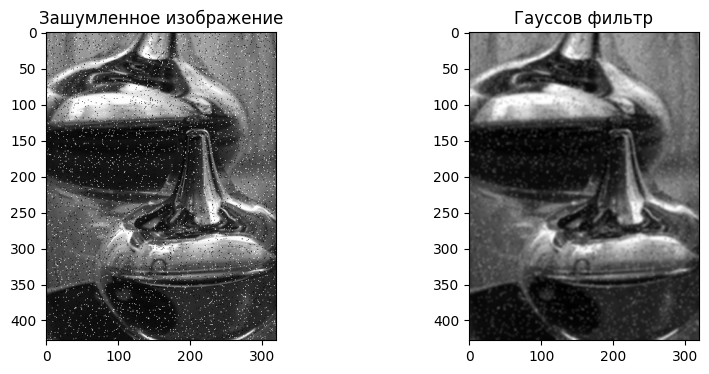

In [3]:
processor = MyImageProcessor()

checkerboard = np.array(Image.open('Noise_salt_and_pepper.png'))


blurred_image = processor.gaussian_filter(checkerboard, kernel_size=5, sigma=1.5)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Зашумленное изображение")
plt.imshow(checkerboard, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Гауссов фильтр")
plt.imshow(blurred_image, cmap='gray')
plt.show()

### Задание 2. Медианный фильтр

Дополните класс **`MyImageProcessor`**, реализовав метод `median_filter`.
Медианный фильтр заменяет значение каждого пикселя медианой значений
в его окрестности. Используйте функцию `cv2.medianBlur`.

*Подсказка:* медианный фильтр является нелинейным и часто используется для
уменьшения импульсного шума, сохраняя при этом границы объектов.


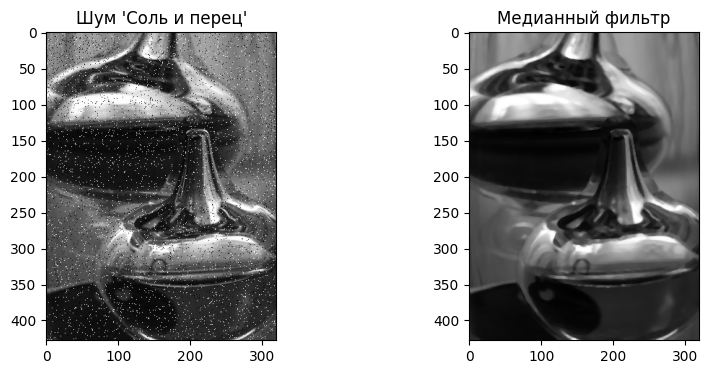

In [4]:
sp_noise_img = checkerboard.copy()
salt_coords =[np.random.randint(0, 100, 100), np.random.randint(0, 100, 100)]
pepper_coords =[np.random.randint(0, 100, 100), np.random.randint(0, 100, 100)]
sp_noise_img[tuple(salt_coords)] = 1.0
sp_noise_img[tuple(pepper_coords)] = 0.0

median_filtered = processor.median_filter(sp_noise_img, kernel_size=5)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Шум 'Соль и перец'")
plt.imshow(sp_noise_img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Медианный фильтр")
plt.imshow(median_filtered, cmap='gray')
plt.show()

### Задание 3. Средний (усредняющий) фильтр

Добавьте в класс **`MyImageProcessor`** метод `mean_filter`. Этот метод
должен применять усредняющий фильтр, который заменяет каждый пиксель
средним значением пикселей в окне заданного размера. Используйте
функцию `cv2.blur` (или `cv2.boxFilter`).


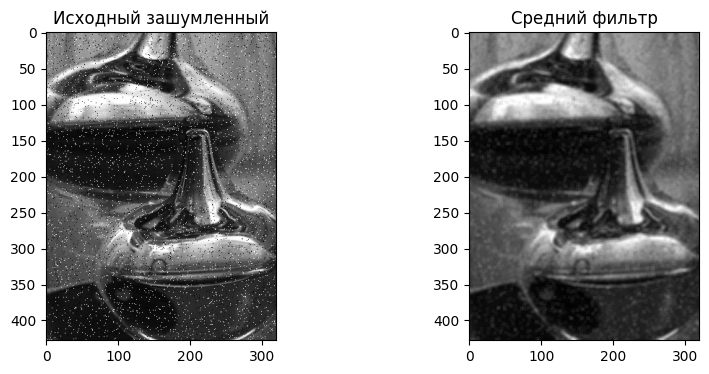

In [5]:
mean_filtered = processor.mean_filter(checkerboard, kernel_size=5)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Исходный зашумленный")
plt.imshow(checkerboard, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Средний фильтр")
plt.imshow(mean_filtered, cmap='gray')
plt.show()

### Задание 4. Низкочастотная фильтрация в частотной области

Реализуйте метод `fourier_lowpass_filter`. Этот метод должен:

1. Преобразовать изображение из пространственной области в частотную
   с помощью двухмерного БПФ (`np.fft.fft2`), затем сдвинуть нулевую
   частоту в центр (`np.fft.fftshift`).
2. Создать бинарную маску размером как изображение, в которой единицы
   расположены в круге радиуса `radius` вокруг центра, а остальная
   область заполнена нулями.
3. Умножить спектр изображения на маску (фильтрация) и выполнить
   обратное смещение (`np.fft.ifftshift`) и обратное БПФ (`np.fft.ifft2`).
4. Вернуть модуль (реальную часть) полученного изображения.

Такой фильтр позволяет удалять высокочастотные детали, сохраняя
низкочастотную структуру.


Найденное смещение (offset): 16


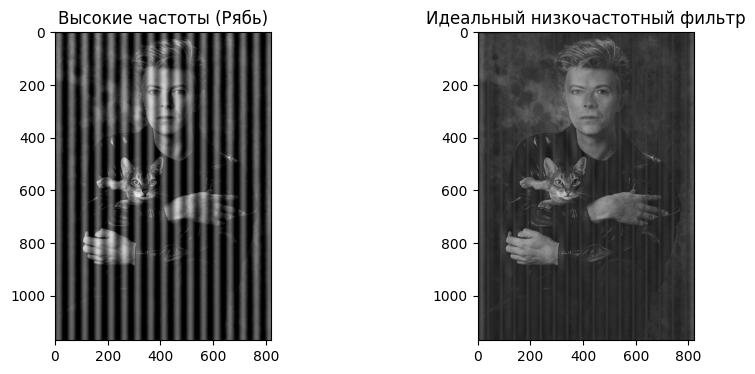

In [6]:
im_array = np.array(Image.open('pic.jpg').convert('L'))
h,w = im_array.shape
amplitude = 60
frequency = 50
y, x = np.ogrid[:h, :w]
noise = amplitude * np.sin(2 * np.pi * x / frequency)

if len(im_array.shape) == 3:
    noise = np.repeat(noise[:, :, np.newaxis], 3, axis=2)
    
new_im_array = np.clip(im_array.astype(np.float32) + noise, 0, 255).astype(np.uint8)


fft_filtered = processor.fourier_lowpass_filter(new_im_array)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Высокие частоты (Рябь)")
plt.imshow(new_im_array, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Идеальный низкочастотный фильтр")
plt.imshow(fft_filtered, cmap='gray')
plt.show()

### Задание 5. Свёртка с произвольным ядром

Реализуйте метод `convolve`. Метод принимает изображение и ядро
(матрицу) и возвращает результат свёртки. Для выполнения свёртки
воспользуйтесь функцией `cv2.filter2D`. Убедитесь, что результат имеет
тот же размер, что и исходное изображение.


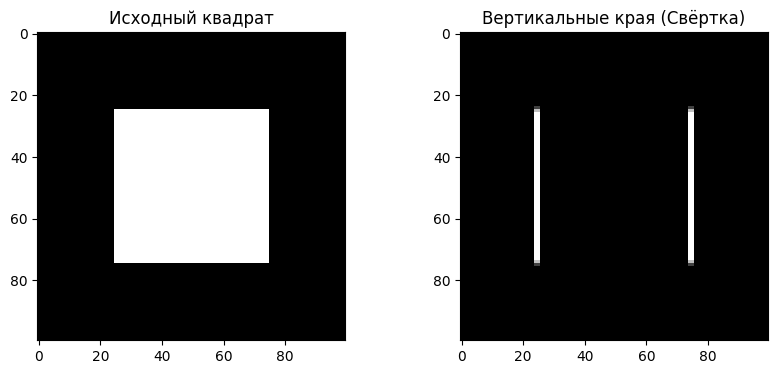

In [7]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

square = np.zeros((100, 100), dtype=np.float32)
square[25:75, 25:75] = 1.0

edges = processor.convolve(square, sobel_x)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Исходный квадрат")
plt.imshow(square, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Вертикальные края (Свёртка)")
plt.imshow(np.abs(edges), cmap='gray')
plt.show()

### Задание 6. Морфологические операции

Реализуйте метод `morphological_operation`. Метод должен поддерживать
следующие значения параметра `operation`:

- `'erosion'` — эрозия (сжатие белых объектов). Используйте `cv2.erode`.
- `'dilation'` — дилатация (расширение белых объектов). Используйте `cv2.dilate`.
- `'opening'` — открытие (эрозия, затем дилатация). Используйте
  `cv2.morphologyEx` с флагом `cv2.MORPH_OPEN`.
- `'closing'` — закрытие (дилатация, затем эрозия). Используйте
  `cv2.morphologyEx` с флагом `cv2.MORPH_CLOSE`.

Создайте структурирующий элемент с помощью `cv2.getStructuringElement`,
например, `cv2.MORPH_RECT` размера `kernel_size × kernel_size`.

*Пример:* морфологическое открытие помогает удалять шум, а закрытие
заполняет маленькие отверстия внутри объектов.


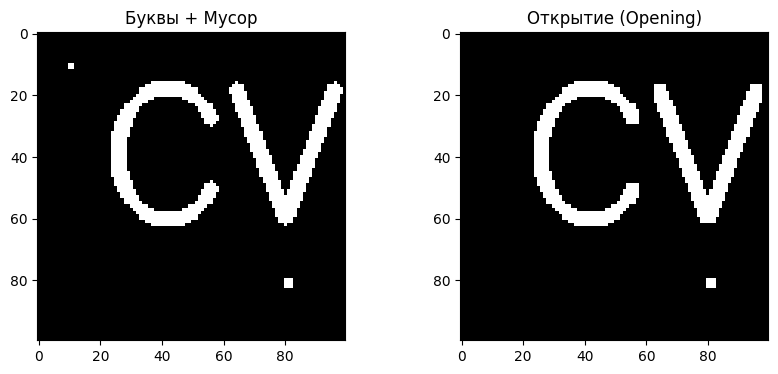

In [8]:
text_img = np.zeros((100, 100), dtype=np.uint8)
cv2.putText(text_img, 'CV', (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 2, 255, 3)

text_img[10:12, 10:12] = 255
text_img[80:83, 80:83] = 255

opened_img = processor.morphological_operation(text_img, 'opening', kernel_size=3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Буквы + Мусор")
plt.imshow(text_img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Открытие (Opening)")
plt.imshow(opened_img, cmap='gray')
plt.show()

### Задание 7. Развёртка изображения в вектор

Реализуйте метод `flatten_image`. Этот метод должен принимать
изображение и возвращать одномерный массив (`numpy.ndarray`),
полученный последовательным чтением всех элементов изображения.
Используйте метод `flatten()` библиотеки NumPy.


In [9]:
dummy = np.array([[1, 2], [3, 4]])
print(f"Матрица 2x2:\n{dummy}")
print(f"Вектор (Flatten): {processor.flatten_image(dummy)}")

Матрица 2x2:
[[1 2]
 [3 4]]
Вектор (Flatten): [1 2 3 4]


### Задание 8. Классическая классификация изображений

В этом задании вы примените методы, реализованные в классе
**`MyImageProcessor`**, чтобы подготовить данные для обучения классического
классификатора. Используйте набор данных `load_digits()` из
`sklearn.datasets`:

1. Загрузите изображения и метки (`load_digits(return_X_y=False)`),
   выделите обучающую и тестовую выборки (`train_test_split`).
2. Используя метод `flatten_image`, преобразуйте каждое изображение в
   одномерный вектор признаков.
3. Отмасштабируйте признаки с помощью `StandardScaler`.
4. Обучите логистическую регрессию (`LogisticRegression(max_iter=1000)`) на
   обучающих данных.
5. Оцените точность (`accuracy_score`) на тестовой выборке и выведите
   результат.

*Цель:* показать, как простая модель может классифицировать изображения,
предварительно развернув их в вектор.


In [10]:
X_digits, y_digits = load_digits(return_X_y=True)


images_8x8 = load_digits().images
X_flattened = np.array([processor.flatten_image(img) for img in images_8x8])

X_train, X_test, y_train, y_test = train_test_split(X_flattened, y_digits, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
print(f"Точность (Accuracy) классической логистической регрессии: {accuracy_score(y_test, y_pred):.4f}")

Точность (Accuracy) классической логистической регрессии: 0.9722


### Задание 9. Простая свёрточная нейронная сеть

Теперь вы построите простую свёрточную нейронную сеть (CNN) для
классификации изображений из набора `digits`.

1. Создайте класс `DigitsDataset`, наследующий от `torch.utils.data.Dataset`, который
   в методе `__getitem__` возвращает изображение в виде тензора
   размера `(1, 8, 8)` и соответствующую метку.
2. Определите класс `SimpleCNN`, наследующий от `torch.nn.Module`,
   содержащий два последовательных блока: свёртка → ReLU → подвыборка
   (max pooling), затем полносвязный слой, который выдаёт 10
   выходов (по количеству классов).
3. Разделите данные на обучающую и тестовую выборки, создайте
   `DataLoader` для каждой части.
4. Напишите цикл обучения (несколько эпох) с функцией потерь
   `nn.CrossEntropyLoss` и оптимизатором `optim.Adam`.
5. После обучения рассчитайте точность на тестовой выборке.

*Цель:* сравнить качество CNN с классической моделью из предыдущего задания.


In [11]:
class DigitsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).view(-1, 1, 8, 8)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = DigitsDataset(X_train_scaled, y_train)
test_dataset = DigitsDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
class SimpleCNN(pl.LightningModule):
    def __init__(self, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()

        self.conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1) 
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        self.fc = nn.Linear(8 * 4 * 4, 10) 
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        # [B, 1, 8, 8]
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = x.view(x.size(0), -1) # [B, 128]
        x = self.fc(x)            # [B, 10]
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)


In [13]:
trainer_simple = pl.Trainer(max_epochs=15)
model_simple = SimpleCNN(learning_rate=0.01)

trainer_simple.fit(model_simple, train_loader)

model_simple.eval()
y_true, y_pred =[],[]
with torch.no_grad():
    for x, y in test_loader:
        logits = model_simple(x)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())

print(f"Точность SimpleCNN: {accuracy_score(y_true, y_pred):.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs 

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv    │ Conv2d           │     80 │ train │     0 │
│ 1 │ relu    │ ReLU             │      0 │ train │     0 │
│ 2 │ pool    │ MaxPool2d        │      0 │ train │     0 │
│ 3 │ fc      │ Linear           │  1.3 K │ train │     0 │
│ 4 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


`Trainer.fit` stopped: `max_epochs=15` reached.


Точность SimpleCNN: 0.9639


### Задание 10. Сравнение двух архитектур CNN

В последнем задании вам предстоит сравнить две свёрточные сети:

1. Простую сеть из предыдущего задания (`SimpleCNN`).
2. Более глубокую сеть `DeepCNN`, которая включает большее количество
   свёрточных слоёв (например, три блока свёртка–ReLU–max pooling) и
   несколько полносвязных слоёв.

Вам необходимо:

- Реализовать класс `DeepCNN` по аналогии с `SimpleCNN`, увеличив число
  каналов в свёрточных слоях и добавив ещё один полносвязный слой.
- Провести обучение обеих сетей на одинаковом наборе данных. Для
  справедливости используйте одинаковое количество эпох и одинаковый
  оптимизатор.
- Измерить и вывести точность каждой модели на тестовой выборке.
- Сравнить результаты: какая из моделей показала лучшее качество?

*Дополнительно:* обсудите, как изменение глубины и числа параметров
влияет на способность нейронной сети обучаться на небольшом наборе
данных.


In [14]:
class DeepCNN(pl.LightningModule):
    def __init__(self, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), #[B, 16, 8, 8]
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),#[B, 32, 8, 8]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                            # [B, 32, 4, 4]
            nn.Conv2d(32, 64, kernel_size=3, padding=1),# [B, 64, 4, 4]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                             # [B, 64, 2, 2]
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)


In [15]:
trainer_deep = pl.Trainer(max_epochs=15, logger=False, enable_progress_bar=False)
model_deep = DeepCNN(learning_rate=0.01)

trainer_deep.fit(model_deep, train_loader)

model_deep.eval()
y_true_deep, y_pred_deep = [],[]
with torch.no_grad():
    for x, y in test_loader:
        # x: [Batch, 1, 8, 8]
        logits = model_deep(x) #[Batch, 10]
        preds = torch.argmax(logits, dim=1) # [Batch]
        
        y_true_deep.extend(y.numpy())
        y_pred_deep.extend(preds.numpy())

acc_deep = accuracy_score(y_true_deep, y_pred_deep)
print(f"Точность DeepCNN: {acc_deep:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Projects\FU\Course_3\CV\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential       │ 23.5 K │ train │     0 │
│ 1 │ classifier │ Sequential       │ 34.2 K │ train │     0 │
│ 2 │ loss_fn    │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 57.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 57.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=15` reached.


Точность DeepCNN: 0.9944


Более глубокая модель показалала себя лучше